## Deep Learning

### Chapter 6: Cross-Validation in Neural Networks

Cross-validation is a robust technique for evaluating machine learning models by training them on different subsets of the input data and testing them on unseen data. This helps to ensure that the model generalizes well to new data and provides a more reliable estimate of its performance.

Holdout cross-validation is the simplest form, where the dataset is split into a single training set and a single testing set. The model is trained exclusively on the training data and evaluated on the test data.

K-Fold cross-validation divides the dataset into K equal-sized folds. The model is trained K times, each time using K-1 folds for training and one fold for validation, providing K different performance estimates that are then averaged.

**Cross-Validation for Classification Problems**

In [29]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


def build_classification_model():
    hidden_layer1 = layers.Dense(64, activation='relu')
    hidden_layer2 = layers.Dense(32, activation='relu')
    output_layer = layers.Dense(3, activation='softmax')
    model = Sequential([hidden_layer1, hidden_layer2, output_layer])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

This code loads the Iris dataset, a classic dataset for classification tasks, using `sklearn.datasets.load_iris()`. It then extracts the features (`X`) and target labels (`y`) from the loaded dataset.

In [30]:
from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data
y = iris.target

In [31]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=3)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
from sklearn.model_selection import train_test_split
train_data, test_data, train_targets, test_targets = train_test_split(X_scaled, y,
                                                                      test_size=0.2, random_state=42)

In [34]:
K = 5
num_val_samples = len(train_data) // K
num_epochs = 80
classification_histories = []

In [35]:
import numpy as np

for i in range(K):
    print('processing fold #', i + 1)
    val_data = X_scaled[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = y[i * num_val_samples: (i + 1) * num_val_samples]

    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)

    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    model = build_classification_model()
    history = model.fit(
        partial_train_data,
        partial_train_targets,
        epochs=num_epochs,
        batch_size=16,
        verbose=0)

    classification_histories.append(history.history['accuracy'])

average_accuracy = np.mean(classification_histories, axis=0)
print('Average accuracy:', average_accuracy[-1])

processing fold # 1
processing fold # 2
processing fold # 3
processing fold # 4
processing fold # 5
Average accuracy: 0.9854166746139527


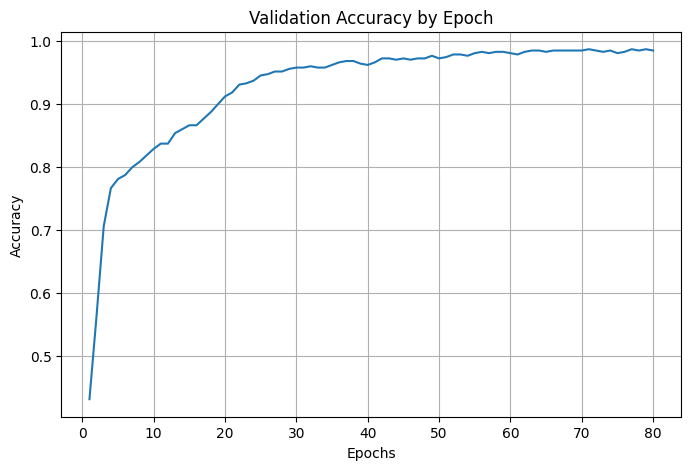

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), average_accuracy)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy by Epoch')
plt.grid(True)
plt.show()

**Cross-Validation for Regression**

In [37]:
from tensorflow.keras.datasets import boston_housing
from tensorflow import keras

(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

In [38]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

train_data -= mean
test_data -= mean

train_data /= std
test_data /= std

In [39]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

def build_regression_model():
    hidden_layer1 = layers.Dense(64, activation='relu')
    hidden_layer2 = layers.Dense(64, activation='relu')
    output_layer = layers.Dense(1)
    model = keras.Sequential([hidden_layer1, hidden_layer2, output_layer])

    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

In [40]:
import numpy as np

k = 5
num_val_samples = len(train_data) // k
num_epochs = 100
all_mae_histories = []

for i in range(k):
    print('processing fold #', i + 1)

    # Set validation fold
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    # Built partial train
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)

    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    # Build regression model
    model = build_regression_model()

    # Train and save history
    history = model.fit(
        partial_train_data,
        partial_train_targets,
        validation_data=(val_data, val_targets),
        epochs=num_epochs,
        batch_size=16,
        verbose=0)

    # Take mae history of current fold and append to all_mae_histories
    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)

# Compute average_mae_history
average_mae_history = [np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

processing fold # 1
processing fold # 2
processing fold # 3
processing fold # 4
processing fold # 5


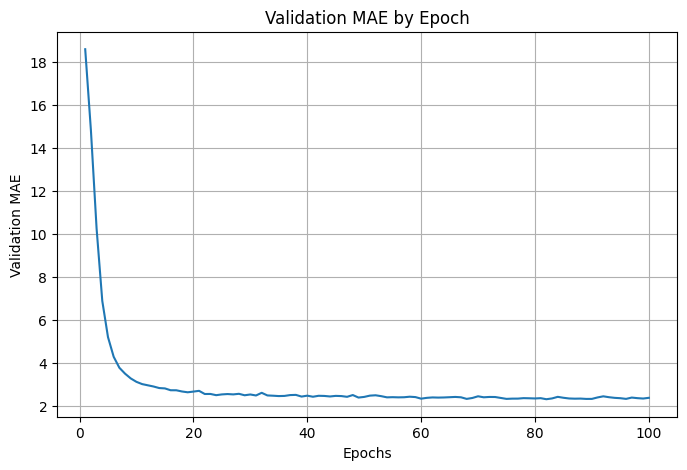

In [41]:
import matplotlib.pyplot as plt

# Plot average_mae_history
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.title('Validation MAE by Epoch')
plt.grid(True)
plt.show()